Installing required modules

In [1]:
%pip install geopandas libpysal esda matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Importing required libraries

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local
import numpy as np

Loding online dataset

In [3]:
# ==============================
# 3. Load Online Vector Dataset
# ==============================

url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"

world = gpd.read_file(url)

# Select Africa countries only
africa = world[world['CONTINENT'] == 'Africa']

print(africa.head())

         featurecla  scalerank  LABELRANK                        SOVEREIGNT  \
1   Admin-0 country          1          3       United Republic of Tanzania   
2   Admin-0 country          1          7                    Western Sahara   
11  Admin-0 country          1          2  Democratic Republic of the Congo   
12  Admin-0 country          1          6                           Somalia   
13  Admin-0 country          1          2                             Kenya   

   SOV_A3  ADM0_DIF  LEVEL               TYPE TLC  \
1     TZA         0      2  Sovereign country   1   
2     SAH         0      2      Indeterminate   1   
11    COD         0      2  Sovereign country   1   
12    SOM         0      2  Sovereign country   1   
13    KEN         0      2  Sovereign country   1   

                               ADMIN  ...     FCLASS_TR     FCLASS_ID  \
1        United Republic of Tanzania  ...          None          None   
2                     Western Sahara  ...  Unrecognized  Unr

Ploting African Countries Map

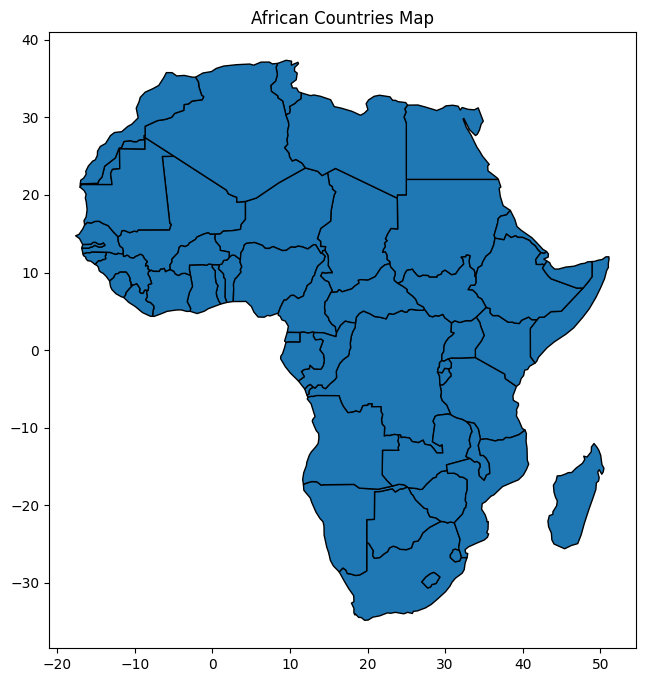

In [4]:
africa.plot(figsize=(10,8), edgecolor='black')
plt.title("African Countries Map")
plt.show()

Create Sample Attribute

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


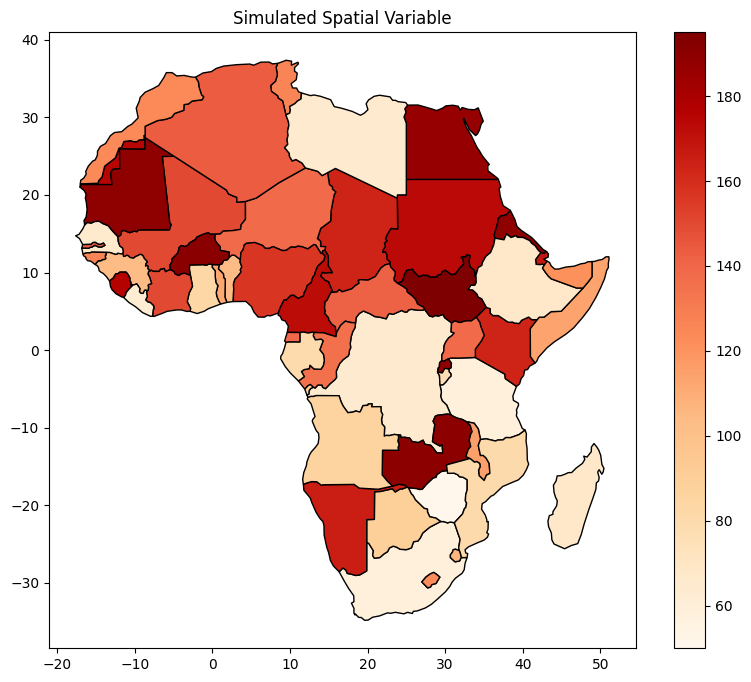

In [5]:
# ==============================
# 5. Create Example Attribute
# ==============================
# We simulate a spatial variable for analysis

np.random.seed(10)
africa["value"] = np.random.randint(50, 200, size=len(africa))

# Plot attribute distribution

africa.plot(column="value",
            cmap="OrRd",
            legend=True,
            figsize=(10,8),
            edgecolor="black")

plt.title("Simulated Spatial Variable")
plt.show()

Creating spatial weights

In [6]:
#create spatial weights matrix using Queen contiguity
w = Queen.from_dataframe(africa)
w.transform = 'r'

print("Number of neighbors for first country:", w[0])

('WARNING: ', 37, ' is an island (no neighbors)')
Number of neighbors for first country: {32: 0.125, 33: 0.125, 2: 0.125, 4: 0.125, 36: 0.125, 48: 0.125, 49: 0.125, 31: 0.125}


C:\Users\HP\AppData\Local\Temp\ipykernel_16712\3774851301.py:2: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(africa)
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
 There is 1 island with id: 37.
  W.__init__(self, neighbors, ids=ids, **kw)
